# Python Data Processing

##### IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### LOAD DATASETS FROM GITHUB

In [ ]:
app_events = pd.read_csv("https://raw.githubusercontent.com/sruthis-as/northstar-analysis/main/app_events_clean.csv")

complaints = pd.read_csv("https://raw.githubusercontent.com/sruthis-as/northstar-analysis/main/complaints_clean.csv")

customers = pd.read_csv("https://raw.githubusercontent.com/sruthis-as/northstar-analysis/main/customers_clean.csv")

deliveries = pd.read_csv("https://raw.githubusercontent.com/sruthis-as/northstar-analysis/main/deliveries_clean.csv")

drivers = pd.read_csv("https://raw.githubusercontent.com/sruthis-as/northstar-analysis/main/drivers_clean.csv")

hubs = pd.read_csv("https://raw.githubusercontent.com/sruthis-as/northstar-analysis/main/hubs.csv")

incidents = pd.read_csv("https://raw.githubusercontent.com/sruthis-as/northstar-analysis/main/incidents_clean.csv")

orders = pd.read_csv("https://raw.githubusercontent.com/sruthis-as/northstar-analysis/main/orders_clean.csv")

vehicles = pd.read_csv("https://raw.githubusercontent.com/sruthis-as/northstar-analysis/main/vehicles_clean.csv")

##### BASIC DATA CHECKING

In [ ]:
deliveries.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,delivery_duration_hours
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05,22.149973
1,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51,1.108991
2,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62,23.985584
3,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22,4.042814
4,DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52.384869,Delayed,13.84,0,0,1.57,9.58,28.531218


In [ ]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 867 entries, 0 to 866
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   delivery_id                    867 non-null    object 
 1   order_id                       867 non-null    object 
 2   driver_id                      867 non-null    object 
 3   vehicle_id                     867 non-null    object 
 4   hub_id                         867 non-null    object 
 5   dispatch_time                  867 non-null    object 
 6   delivery_completed_at          867 non-null    object 
 7   delivery_status                867 non-null    object 
 8   route_distance_km              867 non-null    float64
 9   manual_route_override_count    867 non-null    int64  
 10  proof_of_completion_missing    867 non-null    int64  
 11  customer_rating_post_delivery  867 non-null    float64
 12  fuel_or_charge_cost            867 non-null    flo

##### STATISTICAL SUMMARY

In [ ]:
deliveries.describe()

,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,delivery_duration_hours
count,867.000000,867.000000,867.000000,867.000000,867.000000,867.000000
mean,13.967958,0.966551,0.077278,3.848235,12.872860,10.317151
std,7.522800,1.097988,0.267186,0.901557,4.360239,8.463124
min,1.200000,0.000000,0.000000,1.000000,2.500000,0.022565
25%,9.150000,0.000000,0.000000,3.340000,9.895000,3.501689
50%,12.810000,1.000000,0.000000,4.040000,12.670000,7.913109
75%,16.985000,2.000000,0.000000,4.540000,15.780000,15.528078
max,41.940000,7.000000,1.000000,5.000000,29.430000,43.456918


##### SHAPE OF DATASET

In [ ]:
deliveries.shape

(867, 14)

##### SINGLE COLUMN

In [ ]:
deliveries["delivery_status"]

,delivery_status
0,Failed
1,OnTime
2,Delayed
3,OnTime
4,Delayed
...,...
862,OnTime
863,OnTime
864,OnTime
865,OnTime


##### MULTIPLE COLUMNS

In [ ]:
deliveries[["driver_id", "delivery_status", "fuel_or_charge_cost"]]

,driver_id,delivery_status,fuel_or_charge_cost
0,D004,Failed,12.05
1,D006,OnTime,8.51
2,D116,Delayed,13.62
3,D108,OnTime,9.22
4,D037,Delayed,9.58
...,...,...,...
862,D075,OnTime,12.97
863,D129,OnTime,11.79
864,D155,OnTime,9.38
865,D060,OnTime,20.13


##### BASIC SLICING
First 4 Rows

In [ ]:
deliveries[0:4]

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,delivery_duration_hours
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05,22.149973
1,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51,1.108991
2,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62,23.985584
3,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22,4.042814


SPECIFIC ROWS & COLUMNS

In [ ]:
deliveries.loc[0:5, ["driver_id", "delivery_status"]]

,driver_id,delivery_status
0,D004,Failed
1,D006,OnTime
2,D116,Delayed
3,D108,OnTime
4,D037,Delayed
5,D151,Delayed


##### FILTERING

In [ ]:
failed_deliveries = deliveries[deliveries["delivery_status"] == "failed"]

failed_deliveries.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,delivery_duration_hours


##### MISSING VALUE HANDLING

In [ ]:
deliveries.isnull().sum()

,0
delivery_id,0
order_id,0
driver_id,0
vehicle_id,0
hub_id,0
dispatch_time,0
delivery_completed_at,0
delivery_status,0
route_distance_km,0
manual_route_override_count,0


NUMPY ANALYSIS
1. Average cost

In [ ]:
np.mean(deliveries["fuel_or_charge_cost"])

np.float64(12.872860438292964)

2. Standard deviation

In [ ]:
np.std(deliveries["fuel_or_charge_cost"])

4.357723963095721

##### MERGING DATASET

In [ ]:
merged_data = deliveries.merge(
    orders[["order_id", "pickup_zone"]],
    on="order_id",
    how="left"
)

merged_data.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,delivery_duration_hours,pickup_zone
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05,22.149973,Central
1,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51,1.108991,Central
2,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62,23.985584,South
3,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22,4.042814,Riverside
4,DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52.384869,Delayed,13.84,0,0,1.57,9.58,28.531218,East


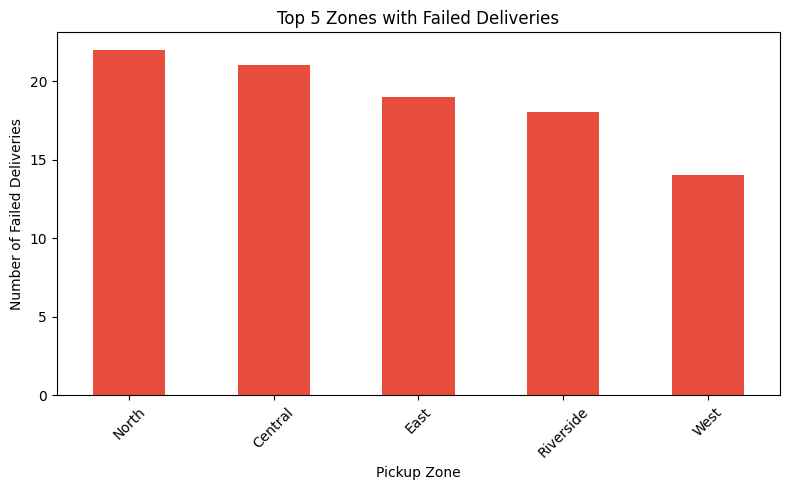

In [ ]:
zone_failures = merged_data[merged_data["delivery_status"].str.lower() == "failed"] \
    .groupby("pickup_zone")["delivery_status"].count() \
    .sort_values(ascending=False).head(5)

plt.figure(figsize=(8, 5))
zone_failures.plot(kind="bar", color="#e74c3c")
plt.title("Top 5 Zones with Failed Deliveries")
plt.xlabel("Pickup Zone")
plt.ylabel("Number of Failed Deliveries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### A Seaborn histogram created using sns.histplot()

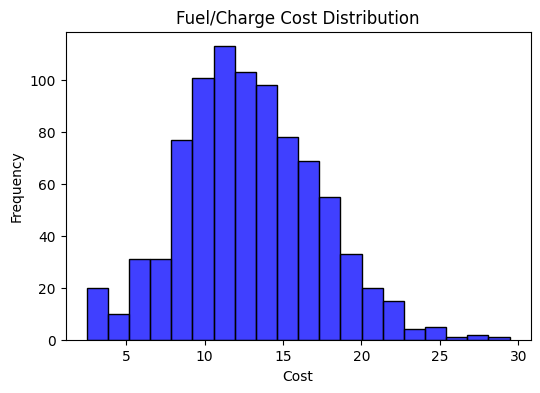

In [ ]:
plt.figure(figsize=(6,4))

sns.histplot(
    deliveries["fuel_or_charge_cost"],
    bins=20,
    color="blue"
)

plt.title("Fuel/Charge Cost Distribution")
plt.xlabel("Cost")
plt.ylabel("Frequency")

plt.show()

##### Bar Chart (Bar Plot)

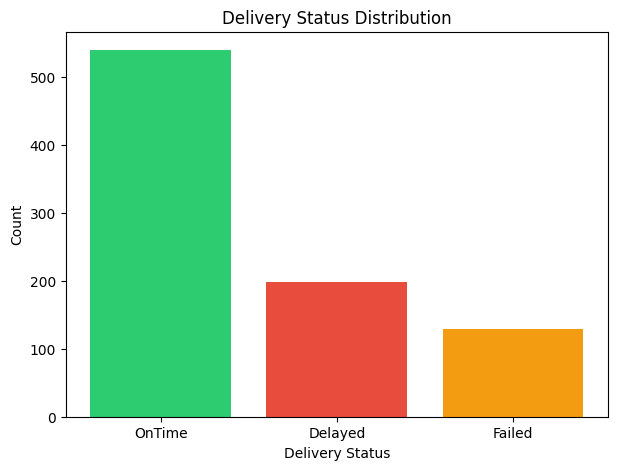

In [ ]:
plt.figure(figsize=(7,5))

status_counts = deliveries["delivery_status"].value_counts()

plt.bar(
    status_counts.index,
    status_counts.values,
    color=["#2ecc71", "#e74c3c", "#f39c12"]
)

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Count")

plt.show()

##### Histogram created using plt.hist

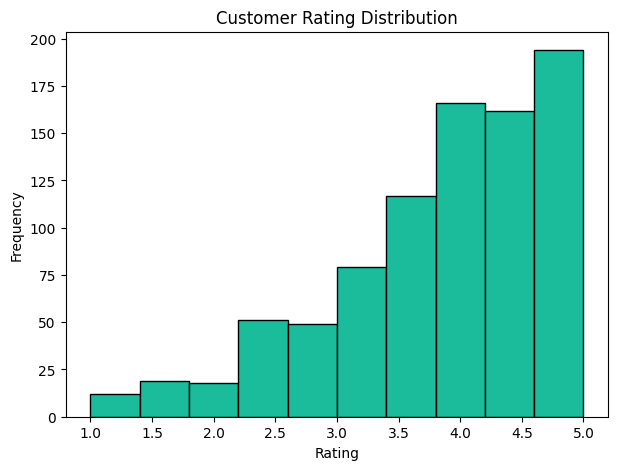

In [ ]:
plt.figure(figsize=(7,5))

plt.hist(
    deliveries["customer_rating_post_delivery"],
    bins=10,
    color="#1abc9c",
    edgecolor="black"
)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

##### scatter plot using plt.scatter

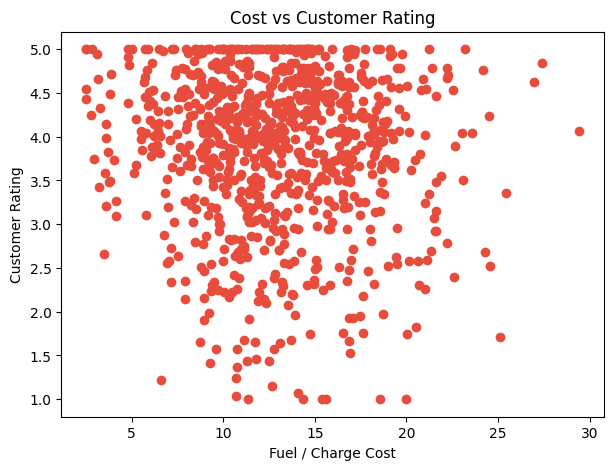

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(
    deliveries["fuel_or_charge_cost"],
    deliveries["customer_rating_post_delivery"],
    color="#e74c3c"
)

plt.title("Cost vs Customer Rating")
plt.xlabel("Fuel / Charge Cost")
plt.ylabel("Customer Rating")

plt.show()

##### sns.pairplot()

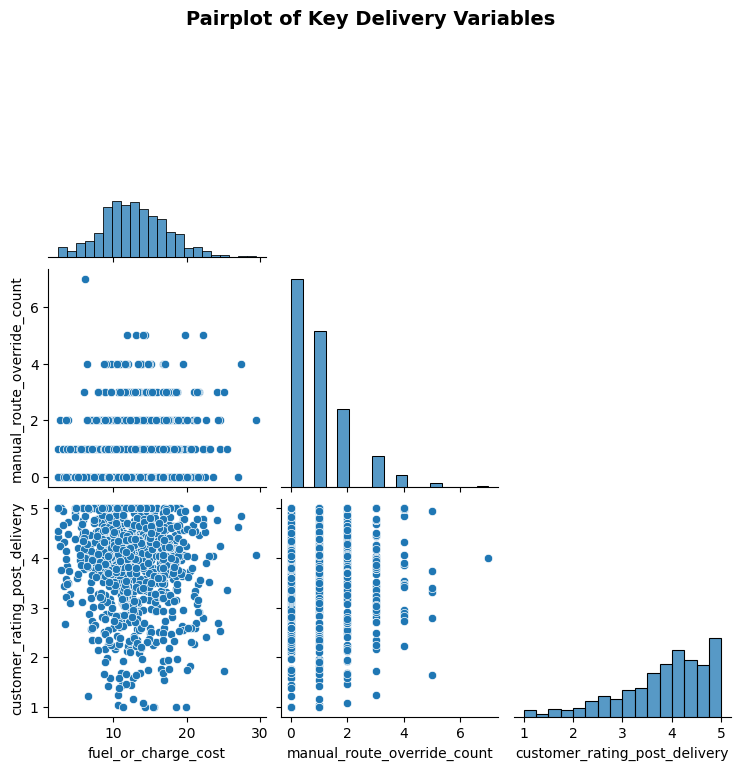

In [ ]:
pair_data = deliveries[[
    "fuel_or_charge_cost",
    "manual_route_override_count",
    "customer_rating_post_delivery"
]]

sns.pairplot(
    pair_data,
    diag_kind="hist",
    corner=True
)

plt.suptitle(
    "Pairplot of Key Delivery Variables",
    y=1.02,
    fontsize=14,
    fontweight="bold"
)

plt.show()

##### Correlation Heatmap using sns.heatmap()

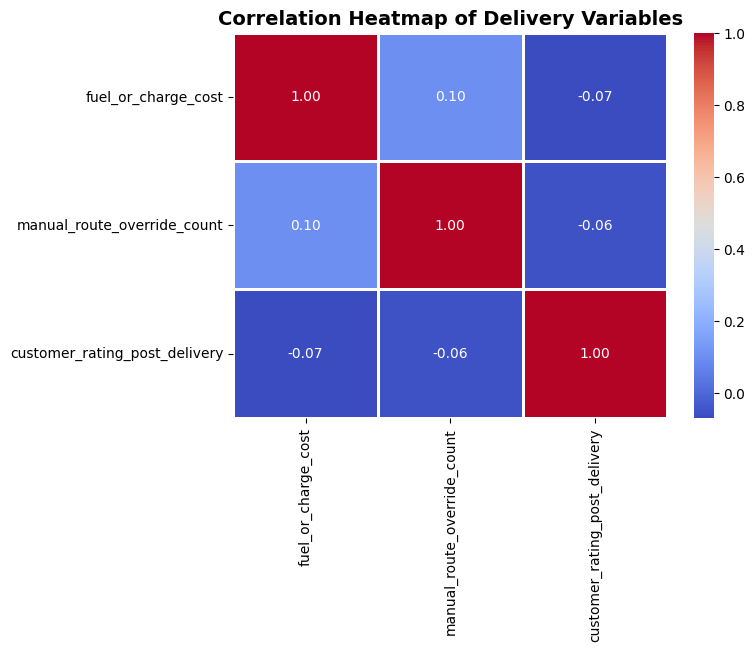

In [ ]:
numeric_data = deliveries[[
    "fuel_or_charge_cost",
    "manual_route_override_count",
    "customer_rating_post_delivery"
]]

correlation_matrix = numeric_data.corr()

plt.figure(figsize=(7,5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=1,
    fmt=".2f"
)

plt.title(
    "Correlation Heatmap of Delivery Variables",
    fontsize=14,
    fontweight="bold"
)

plt.show()

##### BOX PLOT using sns.boxplot

/tmp/ipykernel_1027/1188716939.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


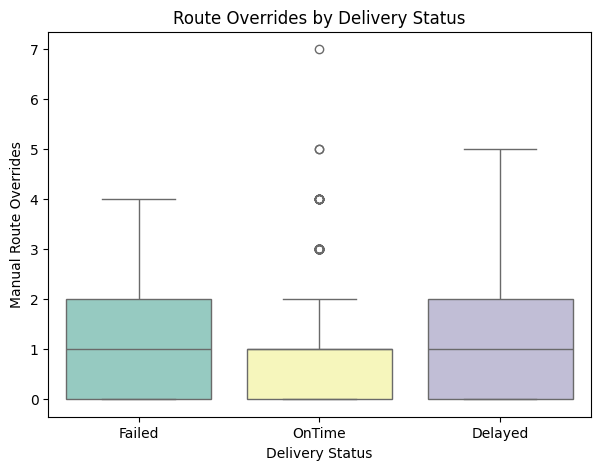

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=deliveries,
    x="delivery_status",
    y="manual_route_override_count",
    palette="Set3"
)

plt.title("Route Overrides by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Manual Route Overrides")

plt.show()

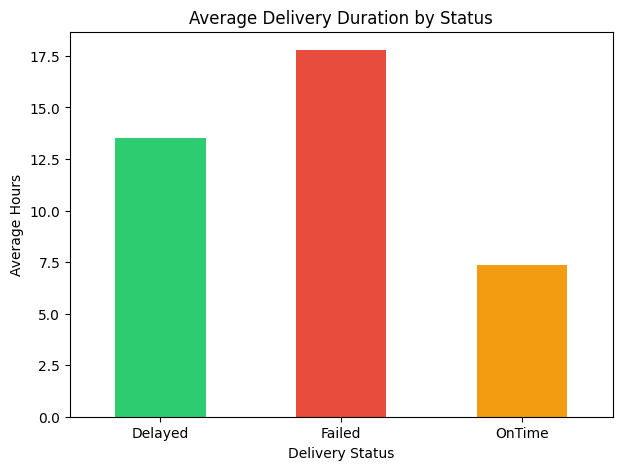

In [ ]:
# Average delivery duration by status
avg_duration = deliveries.groupby("delivery_status")["delivery_duration_hours"].mean()

plt.figure(figsize=(7, 5))
avg_duration.plot(kind="bar", color=["#2ecc71", "#e74c3c", "#f39c12"])
plt.title("Average Delivery Duration by Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Hours")
plt.xticks(rotation=0)
plt.show()

# **Interpretation**

#### This notebook uses pandas, NumPy, matplotlib, and seaborn to explore the cleaned delivery data through statistical analysis and visualisations.

### **Basic Data Inspection**

#### `.head()`, `.info()`, `.describe()`, and `.shape()` were applied to the deliveries dataset. This confirmed column names, data types, and value ranges before analysis began.

### **Column Selection and Filtering**

#### Single and multiple columns were selected to demonstrate targeted data access.

#### A `failed_deliveries` subset was created by filtering on `delivery_status == "failed"` to isolate records most relevant to operational investigation.

### **Missing Value Check**

#### `isnull().sum()` confirmed that no missing values remained after cleaning. This validated that the data used for analysis and visualisation was complete and reliable.

### **NumPy Statistical Analysis**

#### `np.mean(fuel_or_charge_cost)` was used to calculate the average delivery cost.

#### `np.std(fuel_or_charge_cost)` measured the spread of delivery costs. A high standard deviation indicates that some deliveries are significantly more expensive than others and may require investigation.

### **Dataset Merge**

#### Deliveries were merged with orders using `order_id` to add `pickup_zone` information. This join enabled zone-level failure analysis, which could not be performed using the deliveries dataset alone.

### **Bar Chart - Top 5 Zones with Failed Deliveries**

#### This visualisation identified the pickup zones with the highest number of failed deliveries. These zones represent operational problem areas requiring targeted improvement strategies.

### **Histogram - Fuel/Charge Cost Distribution**

#### This histogram showed how delivery costs were distributed across deliveries.

#### A right-skewed distribution indicates that most deliveries have moderate costs while a small number are unusually expensive and may require cost optimisation.

### **Bar Chart - Delivery Status Distribution**

#### This chart compared the number of completed, failed, and delayed deliveries, providing an overall picture of operational performance.

### **Histogram - Customer Rating Distribution**

#### This visualisation showed the spread of post-delivery customer ratings.

#### Ratings concentrated between 4 and 5 indicate strong customer satisfaction, while lower ratings may signal service quality issues.

### **Scatter Plot - Cost vs Customer Rating**

#### This scatter plot explored the relationship between delivery cost and customer rating.

#### A weak or negative correlation suggests that higher delivery spending does not necessarily improve customer satisfaction.

### **Pairplot - Key Delivery Variables**

#### The pairplot visualised relationships between fuel cost, manual route overrides, and customer ratings simultaneously, helping identify multi-variable patterns and trends.

### **Correlation Heatmap**

#### The heatmap quantified relationships between major operational variables.

#### Values closer to +1 or -1 indicate strong relationships, while values near 0 suggest weak or no meaningful relationship.

### **Box Plot - Route Overrides by Delivery Status**

#### This box plot compared manual route override counts across completed, failed, and delayed deliveries.

#### Higher override counts among failed deliveries suggest that deviation from planned routes may contribute to delivery failures.

### **Bar Chart - Average Delivery Duration by Status**

#### This chart compared the average delivery duration for each delivery outcome category.

#### Longer durations for failed or delayed deliveries highlight operational inefficiencies within the delivery process.

# **Overall Conclusion**

#### This notebook identified problematic delivery zones, analysed delivery cost patterns, evaluated customer satisfaction, and explored relationships between key operational variables. These insights provide important evidence for business decision-making and operational improvement at Northstar.